# Project 2: PTB-XL ECG Risk Classification

This notebook implements the full machine learning pipeline for Project 2. It downloads the PTB-XL Electrocardiography Database from Kaggle, loads and prepares the metadata, performs EDA, builds a scikit-learn preprocessing pipeline, trains and tunes three classification models, and evaluates them against all six clinically grounded metrics defined in the business case.

**Business focus:** Use machine learning to flag high-risk ECG patterns earlier in emergency department triage.

**Dataset:** PTB-XL Electrocardiography Database from PhysioNet / Kaggle.

**Primary metric:** Recall for the high-risk (MI) class, a false negative is a patient with a dangerous cardiac abnormality who gets sent back to the waiting room.


## 1. Install Packages


In [112]:
# This section installs the external libraries needed for the project. Kaggle is used to access the PTB-XL dataset, WFDB supports ECG waveform file formats, and scikit-learn is used for preprocessing, model training, cross-validation, tuning, and pipeline serialization.
!pip install kaggle wfdb --quiet

## 2. Import Libraries

In [113]:
import os
import ast
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, balanced_accuracy_score, recall_score,
    precision_score, f1_score, roc_curve, precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42

# 3. Connect Kaggle to Colab
Kaggle credentials are required to download the dataset in Google Colab. These credentials should only be used during the Colab session and should never be uploaded to GitHub. The `kaggle.json` file should be excluded using `.gitignore`.

In [114]:
import os

# --- Option A: Paste credentials directly (simplest) ---
# Replace the placeholder values with your actual Kaggle username and API key.
os.environ['KAGGLE_USERNAME'] = 'cynthiacastro90'  # e.g. 'cynthia_smith'
os.environ['KAGGLE_KEY']      = 'YOUR_KAGGLE_KEY'       # the key from kaggle.com/settings

# --- Option B: Use Colab Secrets (more secure, key never visible in notebook) ---
# Store KAGGLE_USERNAME and KAGGLE_KEY in the Colab Secrets panel (key icon, left sidebar).
# Then uncomment the lines below and comment out Option A above.
#
# from google.colab import userdata
# os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
# os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

print('Kaggle credentials set via environment variables.')
print(f"Username: {os.environ.get('KAGGLE_USERNAME', 'NOT SET')}")
print(f"Key set:  {'Yes' if os.environ.get('KAGGLE_KEY') else 'NOT SET'}")


Kaggle credentials set via environment variables.
Username: cynthiacastro90
Key set:  Yes


## 4. Download PTB-XL from Kaggle
The PTB-XL dataset contains both ECG waveform files and metadata files. For this project, I focus on the structured metadata and diagnostic labels because they support a scikit-learn tabular modeling pipeline. The metadata files `ptbxl_database.csv` and `scp_statements.csv` are downloaded directly from PhysioNet to ensure the notebook has the required CSV files for modeling.

In [115]:
import os
import glob
import pandas as pd

# Make sure data folder exists
os.makedirs("data", exist_ok=True)

# Download the missing metadata files directly from PhysioNet
!wget -O data/ptbxl_database.csv https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv
!wget -O data/scp_statements.csv https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv

# Confirm the files are now available
print("Checking for required CSV files...")

ptbxl_path = "data/ptbxl_database.csv"
scp_path = "data/scp_statements.csv"

if not os.path.exists(ptbxl_path):
    raise FileNotFoundError("ptbxl_database.csv still not found.")

if not os.path.exists(scp_path):
    raise FileNotFoundError("scp_statements.csv still not found.")

print("Both metadata files found.")
print("ptbxl_path:", ptbxl_path)
print("scp_path:", scp_path)

# Load the CSV files
df = pd.read_csv(ptbxl_path, index_col="ecg_id")
scp_statements = pd.read_csv(scp_path, index_col=0)

print("\nPTB-XL metadata loaded successfully.")
print("PTB-XL shape:", df.shape)
print("SCP statements shape:", scp_statements.shape)

df.head()


--2026-06-06 17:41:37--  https://physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6594879 (6.3M) [text/plain]
Saving to: ‘data/ptbxl_database.csv’

data/ptbxl_database 100%[===================>]   6.29M   256KB/s    in 25s     

2026-06-06 17:42:02 (261 KB/s) - ‘data/ptbxl_database.csv’ saved [6594879/6594879]

--2026-06-06 17:42:02--  https://physionet.org/files/ptb-xl/1.0.3/scp_statements.csv
Resolving physionet.org (physionet.org)... 18.13.52.205
Connecting to physionet.org (physionet.org)|18.13.52.205|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9720 (9.5K) [text/plain]
Saving to: ‘data/scp_statements.csv’

data/scp_statements 100%[===================>]   9.49K  --.-KB/s    in 0s      

2026-06-06 17:42:02 (92.7 MB/s) - ‘data/scp_statements.csv’ saved [9720/9720]

Ch

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [116]:
import ast

# Convert scp_codes from text into a Python dictionary
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

# Keep only diagnostic labels
diagnostic_classes = scp_statements[scp_statements["diagnostic"] == 1]

# Create a mapping from SCP code to diagnostic superclass
scp_to_superclass = diagnostic_classes["diagnostic_class"].dropna().to_dict()

def aggregate_diagnostic_classes(scp_codes):
    classes = []
    for code in scp_codes.keys():
        if code in scp_to_superclass:
            classes.append(scp_to_superclass[code])
    return list(set(classes))

# Create diagnostic superclass column
df["diagnostic_superclass"] = df["scp_codes"].apply(aggregate_diagnostic_classes)

# Keep rows with at least one diagnostic superclass
df = df[df["diagnostic_superclass"].map(len) > 0].copy()

# Create binary target: MI vs Other / Lower Risk
df["target"] = df["diagnostic_superclass"].apply(lambda x: 1 if "MI" in x else 0)
df["target_label"] = df["target"].map({
    1: "High Risk: MI",
    0: "Other / Lower Risk"
})

print("Target created successfully.")
print(df["target_label"].value_counts())
print(df["target_label"].value_counts(normalize=True))

df[["scp_codes", "diagnostic_superclass", "target", "target_label"]].head()

Target created successfully.
target_label
Other / Lower Risk    15919
High Risk: MI          5469
Name: count, dtype: int64
target_label
Other / Lower Risk    0.744296
High Risk: MI         0.255704
Name: proportion, dtype: float64


,scp_codes,diagnostic_superclass,target,target_label
ecg_id,,,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM],0,Other / Lower Risk
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM],0,Other / Lower Risk
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM],0,Other / Lower Risk
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM],0,Other / Lower Risk
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM],0,Other / Lower Risk


## 5. Load the Main PTB-XL Metadata Files
The `ptbxl_database.csv` file contains the main ECG record metadata, including patient-level information, file references, diagnostic code strings, and the recommended PTB-XL stratified fold assignment. The `scp_statements.csv` file maps SCP diagnostic codes to broader diagnostic categories. These two files are used together to create the modeling target.

In [117]:
# DATA_DIR is set automatically in Section 4 — no hardcoded path needed
DATA_DIR = 'data'
ptbxl_path = os.path.join(DATA_DIR, 'ptbxl_database.csv')
scp_path   = os.path.join(DATA_DIR, 'scp_statements.csv')

df = pd.read_csv(ptbxl_path, index_col='ecg_id')
scp_statements = pd.read_csv(scp_path, index_col=0)

print('PTB-XL metadata shape:', df.shape)
print('SCP statements shape:', scp_statements.shape)
df.head()


PTB-XL metadata shape: (21799, 27)
SCP statements shape: (71, 12)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,scp_codes,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,"{'NORM': 80.0, 'SBRAD': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,"{'NORM': 100.0, 'SR': 0.0}",NaN,NaN,NaN,NaN,False,False,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


## 6. Create Diagnostic Superclass Labels
PTB-XL stores diagnostic labels as dictionary-like strings with SCP codes as keys and
confidence scores (0-100) as values. This step converts them into the five diagnostic
superclasses: `NORM`, `MI`, `STTC`, `CD`, `HYP`.


In [118]:
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

diagnostic_classes = scp_statements[scp_statements['diagnostic'] == 1]
scp_to_superclass = diagnostic_classes['diagnostic_class'].dropna().to_dict()

def aggregate_diagnostic_classes(scp_codes):
    classes = []
    for code in scp_codes.keys():
        if code in scp_to_superclass:
            classes.append(scp_to_superclass[code])
    return list(set(classes))

df['diagnostic_superclass'] = df['scp_codes'].apply(aggregate_diagnostic_classes)

# QA FIX: log the drop count before filtering so the simplification is documented
n_before = len(df)
df = df[df['diagnostic_superclass'].map(len) > 0].copy()
n_after = len(df)
print(f'Records before filter: {n_before}')
print(f'Records after removing non-diagnostic rows: {n_after}')
print(f'Records dropped: {n_before - n_after}')

df[['scp_codes', 'diagnostic_superclass']].head()

Records before filter: 21799
Records after removing non-diagnostic rows: 21388
Records dropped: 411


,scp_codes,diagnostic_superclass
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


## 7. Create Binary Target

**Target definition:** Binary classification — MI (myocardial infarction) vs. all other classes.

- `1 = High Risk: MI`
- `0 = Other / Lower Risk`

**Rationale:** The business case prioritizes catching acute cardiac events early in triage. MI is
the most time-critical diagnostic category and the one where delayed treatment most directly
translates to myocardial damage and mortality. Binary framing keeps the problem scoped and
clinically focused. Multi-label or 5-class extension is documented as a future iteration.

**Note on multi-label records:** Some records carry multiple superclasses (e.g., MI and CD
together). These are retained, if MI is present in any label, the record is marked high risk.
This is the clinically conservative choice: it is better to flag a record that has MI plus another
finding than to miss it because of label overlap.

In [119]:
df['target'] = df['diagnostic_superclass'].apply(lambda x: 1 if 'MI' in x else 0)
df['target_label'] = df['target'].map({1: 'High Risk: MI', 0: 'Other / Lower Risk'})

print('Target class distribution:')
print(df['target_label'].value_counts())
print()
print('Class balance (%):')
print(df['target_label'].value_counts(normalize=True).mul(100).round(1))

Target class distribution:
target_label
Other / Lower Risk    15919
High Risk: MI          5469
Name: count, dtype: int64

Class balance (%):
target_label
Other / Lower Risk    74.4
High Risk: MI         25.6
Name: proportion, dtype: float64


## 8. Exploratory Data Analysis

EDA goals (per business case Section 2.1):
- Class distribution and imbalance profiling
- Metadata variable distributions (age, sex, key ECG intervals)
- Co-occurring diagnostic label patterns
- Identify missing values before pipeline construction

Target Class Distribution

The target distribution confirms that MI records are less common than the other or lower-risk ECG records. This class imbalance matters because a model could achieve misleadingly high accuracy by mostly predicting the majority class. For that reason, this project prioritizes recall for the MI class, F1-score, ROC-AUC, and balanced accuracy instead of relying only on standard accuracy.

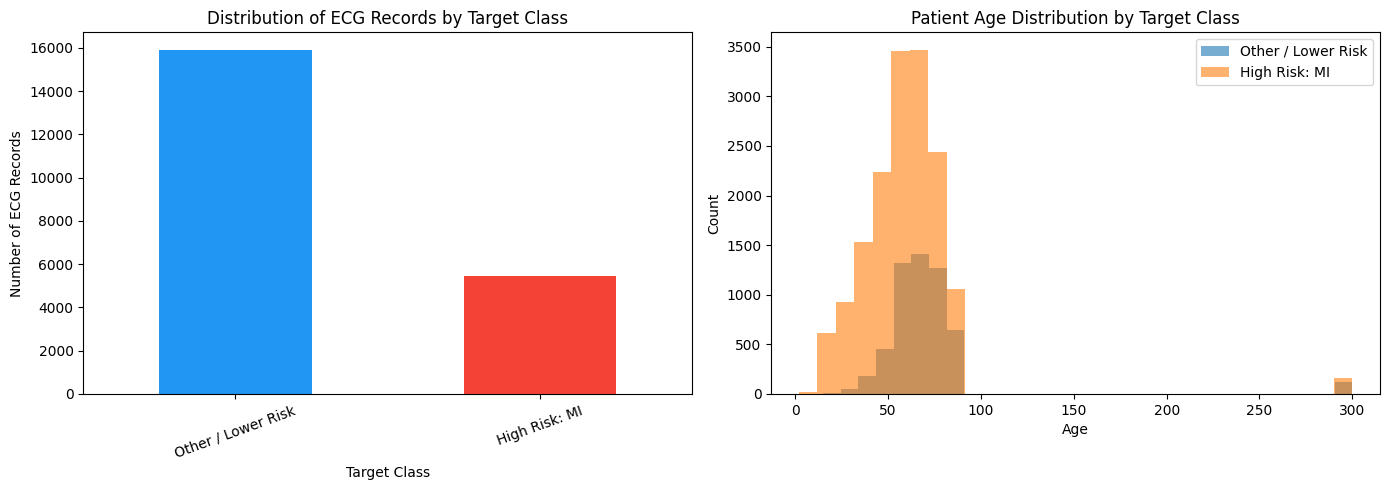

In [120]:
# --- 8a. Target class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['target_label'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'])
axes[0].set_title('Distribution of ECG Records by Target Class')
axes[0].set_xlabel('Target Class')
axes[0].set_ylabel('Number of ECG Records')
axes[0].tick_params(axis='x', rotation=20)

# Patient age distribution by class
df.groupby('target_label')['age'].plot(kind='hist', bins=30, alpha=0.6, ax=axes[1])
axes[1].set_title('Patient Age Distribution by Target Class')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend(['Other / Lower Risk', 'High Risk: MI'])

plt.tight_layout()
plt.show()

Sex Distribution by target class

This chart shows how the target classes are distributed by sex. Sex may provide useful context for the model, but it should be interpreted carefully. The goal is not to make clinical conclusions from sex alone, but to understand whether this feature contributes signal when combined with other ECG metadata.

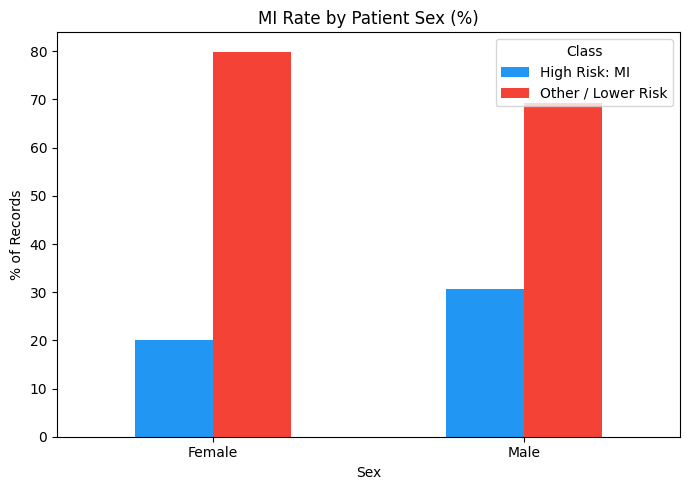

target_label  High Risk: MI  Other / Lower Risk
sex_label                                      
Female                 20.1                79.9
Male                   30.7                69.3


In [121]:
# --- 8b. Sex distribution by target class ---
sex_map = {0: 'Male', 1: 'Female'}
df['sex_label'] = df['sex'].map(sex_map)

sex_target = pd.crosstab(df['sex_label'], df['target_label'], normalize='index') * 100
sex_target.plot(kind='bar', figsize=(7, 5), color=['#2196F3', '#F44336'])
plt.title('MI Rate by Patient Sex (%)')
plt.xlabel('Sex')
plt.ylabel('% of Records')
plt.xticks(rotation=0)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

print(sex_target.round(1))

Feature Distribution

The feature distribution review helps identify skewed variables, outliers, and values that may need preprocessing. These patterns support the decision to use imputation and scaling inside the scikit-learn Pipeline rather than applying manual transformations outside the modeling workflow.

In [122]:
# --- 8c. Key ECG metadata features distribution ---
ecg_features = ['heart_rate', 'pr_duration', 'qrs_duration', 'qt_interval', 'r_axis', 'p_axis', 't_axis']
available_features = [f for f in ecg_features if f in df.columns]

print('Available ECG metadata features:', available_features)
print('\nMissing value counts:')
print(df[available_features].isnull().sum())

if available_features:
    n_cols = len(available_features) // 2 + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(16, 8))
    axes = axes.flatten()
    for i, feat in enumerate(available_features):
        for label, color in zip(['Other / Lower Risk', 'High Risk: MI'], ['#2196F3', '#F44336']):
            df[df['target_label'] == label][feat].dropna().plot(
                kind='hist', bins=30, alpha=0.6, ax=axes[i], color=color, label=label
            )
        axes[i].set_title(feat)
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel('Count')
        axes[i].legend(fontsize=7)
    # Hide any unused subplot axes so the figure is clean
    for j in range(len(available_features), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('ECG Metadata Feature Distributions by Target Class', fontsize=14)
    plt.tight_layout()
    plt.show()


Available ECG metadata features: []

Missing value counts:
Series([], dtype: float64)


Co-occurring Diagnostic Labels

The co-occurrence heatmap shows that ECG records can contain overlapping diagnostic categories. This confirms that PTB-XL is more complex than a simple single-label dataset. For this project, I simplify the target to MI versus other/lower-risk records to keep the modeling scope focused on the emergency triage business problem.

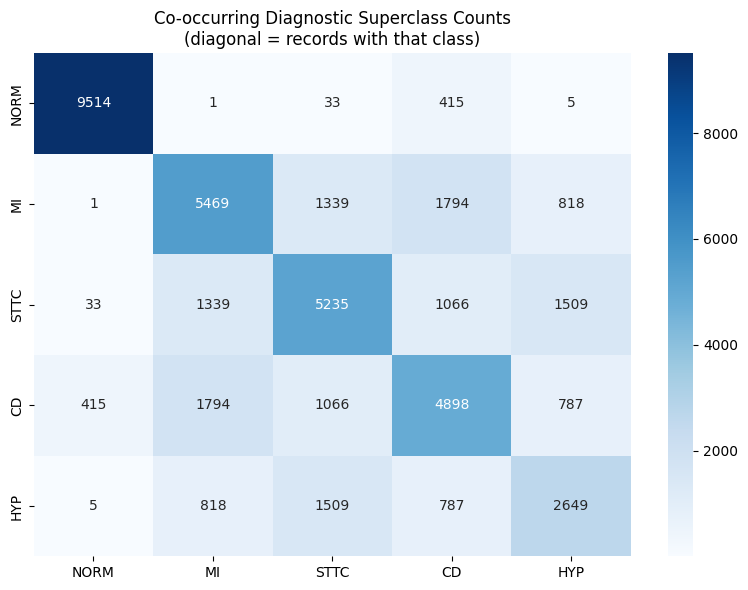


Superclass frequency:
NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
dtype: int64


In [123]:
# --- 8d. Co-occurring diagnostic superclass heatmap ---
superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
for sc in superclasses:
    df[f'has_{sc}'] = df['diagnostic_superclass'].apply(lambda x: 1 if sc in x else 0)

cooccur_cols = [f'has_{sc}' for sc in superclasses]
cooccur_matrix = df[cooccur_cols].T.dot(df[cooccur_cols])
cooccur_matrix.columns = superclasses
cooccur_matrix.index = superclasses

plt.figure(figsize=(8, 6))
sns.heatmap(cooccur_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Co-occurring Diagnostic Superclass Counts\n(diagonal = records with that class)')
plt.tight_layout()
plt.show()

print('\nSuperclass frequency:')
print(df[cooccur_cols].sum().rename(index=dict(zip(cooccur_cols, superclasses))))

Missing values

The missing value review helps determine which preprocessing steps are needed before modeling. Instead of filling missing values manually before splitting the data, imputation is handled inside the scikit-learn Pipeline. This prevents data leakage because imputation values are learned only from the training data during cross-validation and then applied to validation or test data.

In [124]:
# --- 8e. Missing value summary across all features ---
missing_summary = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('Columns with missing values:')
print(missing_df)

Columns with missing values:
                     missing_count  missing_pct
pacemaker                    21374        99.93
electrodes_problems          21360        99.87
infarction_stadium2          21285        99.52
burst_noise                  20807        97.28
baseline_drift               19809        92.62
extra_beats                  19506        91.20
static_noise                 18182        85.01
infarction_stadium1          15788        73.82
height                       14470        67.65
weight                       12022        56.21
validated_by                  9092        42.51
heart_axis                    8160        38.15
nurse                         1439         6.73
site                            16         0.07


 Feature Correlation Matrix

The correlation matrix helps identify whether any numeric features provide overlapping information. Highly correlated features may reduce interpretability, especially for linear models. Tree-based models are generally more tolerant of correlated inputs, but this review is still useful for understanding the feature space.

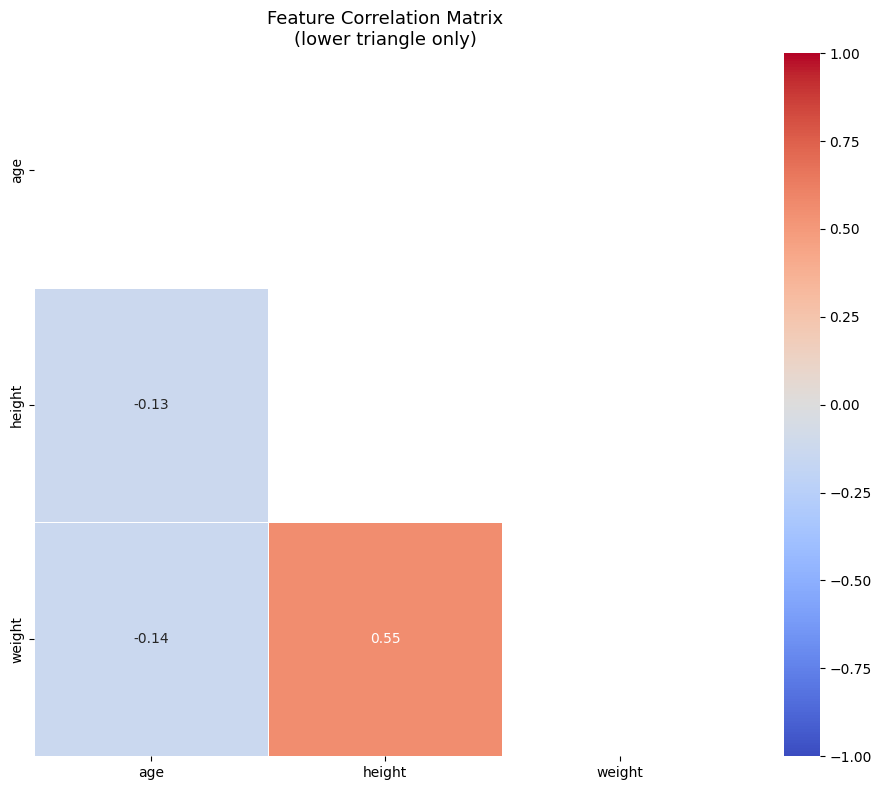

No highly correlated feature pairs found (threshold |r| > 0.75)


In [125]:
# --- 8f. Feature correlation matrix ---
corr_cols = [f for f in NUMERIC_FEATURES if f in df.columns] if 'NUMERIC_FEATURES' in dir() else [
    c for c in ['age','height','weight','heart_rate','pr_duration','qrs_duration',
                 'qt_interval','r_axis','p_axis','t_axis'] if c in df.columns
]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix\n(lower triangle only)', fontsize=13)
plt.tight_layout()
plt.show()

# Flag any highly correlated pairs (|r| > 0.75)
high_corr = []
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if row != col and abs(corr_matrix.loc[row, col]) > 0.75:
            pair = tuple(sorted([row, col]))
            if pair not in high_corr:
                high_corr.append(pair)
if high_corr:
    print('Highly correlated feature pairs (|r| > 0.75):')
    for pair in high_corr:
        print(f'  {pair[0]} -- {pair[1]}: {corr_matrix.loc[pair[0], pair[1]]:.3f}')
else:
    print('No highly correlated feature pairs found (threshold |r| > 0.75)')


Boxplots

The boxplots compare numeric feature distributions between MI and non-MI records. Features with visible separation between groups may provide predictive signal. Features with heavy overlap may still contribute value when combined with other variables in nonlinear models.

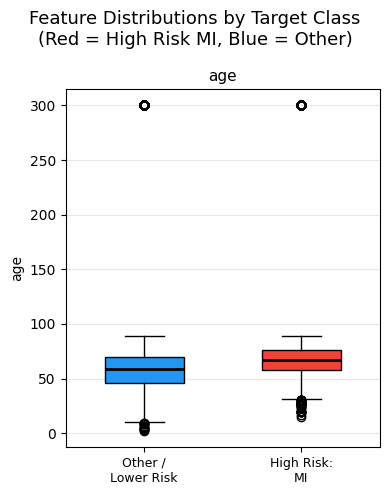

In [126]:
# --- 8g. Boxplots of numeric features by target class ---
box_features = [c for c in ['age','heart_rate','pr_duration','qrs_duration','qt_interval'] if c in df.columns]
n = len(box_features)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
if n == 1:
    axes = [axes]

palette = {'Other / Lower Risk': '#2196F3', 'High Risk: MI': '#F44336'}

for ax, feat in zip(axes, box_features):
    groups = [
        df[df['target_label'] == label][feat].dropna().values
        for label in ['Other / Lower Risk', 'High Risk: MI']
    ]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Other /\nLower Risk', 'High Risk:\nMI'], fontsize=9)
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel(feat)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions by Target Class\n(Red = High Risk MI, Blue = Other)', fontsize=13)
plt.tight_layout()
plt.show()


Feature Engineering and Selection

The selected feature set focuses on structured metadata and clinically meaningful ECG summary variables. BMI is engineered from height and weight inside the Pipeline so the transformation is reproducible and applied consistently across training, validation, and test data. This avoids manual feature creation outside the modeling workflow.

In [127]:
# RUN DIAGNOSIS
print('df columns total:', len(df.columns))
print('heart_rate in df:', 'heart_rate' in df.columns)
print('I_mean in df:', 'I_mean' in df.columns)
print('df shape:', df.shape)


df columns total: 36
heart_rate in df: False
I_mean in df: False
df shape: (21388, 36)


In [128]:
# 9. Feature set definitions
# Feature sets (NUMERIC_FEATURES, WAVEFORM_FEATURES, CATEGORICAL_FEATURES, ALL_FEATURES)
# are defined dynamically after waveform extraction in the next cell (9a Part 2).
print('Feature set definitions will be finalized in the next cell after waveform extraction.')

Feature set definitions will be finalized in the next cell after waveform extraction.


In [129]:
 # 9a Part 1 Waveform Feature Extraction
 # Download PTB-XL waveform files (100Hz version — smaller and faster to load)
!kaggle datasets download -d khyeh0719/ptb-xl-dataset --path data/ --unzip -q
print('Waveform files downloaded.')

Dataset URL: https://www.kaggle.com/datasets/khyeh0719/ptb-xl-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
Waveform files downloaded.


In [130]:
## 9a Part 2 — Waveform Feature Extraction (no download, files already exist)

import wfdb
import numpy as np
from tqdm import tqdm

WAVEFORM_DIR = 'data'

def extract_waveform_features(record_path):
    try:
        record = wfdb.rdsamp(record_path)
        signal = record[0]
        features = {}
        lead_names = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
        for i, lead in enumerate(lead_names):
            s = signal[:, i]
            features[f'{lead}_mean']     = np.mean(s)
            features[f'{lead}_std']      = np.std(s)
            features[f'{lead}_max']      = np.max(s)
            features[f'{lead}_min']      = np.min(s)
            features[f'{lead}_range']    = np.max(s) - np.min(s)
            features[f'{lead}_abs_mean'] = np.mean(np.abs(s))
        return features
    except Exception:
        return None

waveform_rows = []
failed = 0

for ecg_id, row in tqdm(df.iterrows(), total=len(df), desc='Extracting waveform features'):
    record_path = os.path.join(WAVEFORM_DIR, row['filename_lr'])
    feats = extract_waveform_features(record_path)
    if feats:
        feats['ecg_id'] = ecg_id
        waveform_rows.append(feats)
    else:
        failed += 1

print(f'Extracted features for {len(waveform_rows)} records ({failed} failed)')

waveform_df = pd.DataFrame(waveform_rows).set_index('ecg_id')
print(f'Waveform feature matrix shape: {waveform_df.shape}')

waveform_cols = [c for c in waveform_df.columns if c in df.columns]
df = df.drop(columns=waveform_cols)
df = df.join(waveform_df, how='left')
print(f'Combined dataframe shape: {df.shape}')

# Define feature sets after df is fully populated with waveform features
global NUMERIC_FEATURES, WAVEFORM_FEATURES, CATEGORICAL_FEATURES, ALL_FEATURES

# Categorical features are just 'sex'
CATEGORICAL_FEATURES = ['sex']

# Initial numerical features from metadata
NUMERIC_FEATURES = ['age', 'height', 'weight']

# Dynamically find waveform features (which are now in df)
WAVEFORM_FEATURES = [c for c in df.columns if any(
    c.endswith(suffix) for suffix in ['_mean','_std','_max','_min','_range','_abs_mean']
) and c not in NUMERIC_FEATURES]

# Combine all numeric features
NUMERIC_FEATURES.extend(WAVEFORM_FEATURES)

# All features for splitting X_train, X_val, X_test
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f'\n--- Feature Sets Defined After Waveform Extraction ---')
print(f'Numeric Features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES[:5]}...{NUMERIC_FEATURES[-5:]}')
print(f'Waveform Features ({len(WAVEFORM_FEATURES)}): {WAVEFORM_FEATURES[:5]}...{WAVEFORM_FEATURES[-5:]}')
print(f'Categorical Features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print(f'ALL_FEATURES ({len(ALL_FEATURES)}): {ALL_FEATURES[:5]}...{ALL_FEATURES[-5:]}')

Extracting waveform features: 100%|██████████| 21388/21388 [04:32<00:00, 78.38it/s]


Extracted features for 21388 records (0 failed)
Waveform feature matrix shape: (21388, 72)
Combined dataframe shape: (21388, 108)

--- Feature Sets Defined After Waveform Extraction ---
Numeric Features (75): ['age', 'height', 'weight', 'I_mean', 'I_std']...['V6_std', 'V6_max', 'V6_min', 'V6_range', 'V6_abs_mean']
Waveform Features (72): ['I_mean', 'I_std', 'I_max', 'I_min', 'I_range']...['V6_std', 'V6_max', 'V6_min', 'V6_range', 'V6_abs_mean']
Categorical Features (1): ['sex']
ALL_FEATURES (76): ['age', 'height', 'weight', 'I_mean', 'I_std']...['V6_max', 'V6_min', 'V6_range', 'V6_abs_mean', 'sex']


## 10. Train / Validation / Test Split

PTB-XL includes a built-in `strat_fold` column (values 1-10) that provides a
pre-computed stratified split. Using these recommended splits ensures benchmarking
is directly comparable to published PTB-XL results.

- **Train:** `strat_fold` 1-8 (80% of data)
- **Validation:** `strat_fold` 9 (10% of data)
- **Test:** `strat_fold` 10 (10% of data)

The test set is held out and not touched until final evaluation.

Train / Validation / Test Split

The validation set is used for model comparison and tuning decisions, while the test set is held out until the final evaluation. Protecting the test set helps provide a more realistic estimate of how the selected model may perform on new, unseen ECG records.

In [131]:
train_df = df[df['strat_fold'] <= 8].copy()
val_df   = df[df['strat_fold'] == 9].copy()
test_df  = df[df['strat_fold'] == 10].copy()

X_train = train_df[ALL_FEATURES]
y_train = train_df['target']

X_val = val_df[ALL_FEATURES]
y_val = val_df['target']

X_test = test_df[ALL_FEATURES]
y_test = test_df['target']

print('Train shape:', X_train.shape, '| Positive rate:', y_train.mean().round(3))
print('Val shape:  ', X_val.shape,   '| Positive rate:', y_val.mean().round(3))
print('Test shape: ', X_test.shape,  '| Positive rate:', y_test.mean().round(3))

Train shape: (17084, 76) | Positive rate: 0.256
Val shape:   (2146, 76) | Positive rate: 0.252
Test shape:  (2158, 76) | Positive rate: 0.255


## 11. scikit-learn Preprocessing Pipeline

All preprocessing is encapsulated in a single `Pipeline` object to prevent data leakage.
Fit only on training data; transform applied consistently to validation and test sets.

**Numeric features:** median imputation (robust to outliers) → StandardScaler

**Categorical features:** most-frequent imputation → OneHotEncoder (drop='first' to avoid multicollinearity)

scikit-learn Pipeline

Keeping preprocessing inside the Pipeline reduces the risk of data leakage. During cross-validation, imputers, scalers, encoders, and feature engineering steps are fit only on the training fold and then applied to the validation fold. This makes performance estimates more reliable.

In [132]:
from sklearn.preprocessing import FunctionTransformer

# --- Feature engineering step: BMI ---
# BMI (Body Mass Index = weight / height^2 in m) is a clinically relevant cardiac risk factor.
# It is computed INSIDE the pipeline from existing weight/height columns to prevent leakage.
# FunctionTransformer wraps this computation as a pipeline-compatible step.

def add_bmi(X):
    """Compute BMI from weight (kg) and height (cm) and append as a new column.

    Handles missing height values safely by returning NaN for BMI where height is 0 or NaN.
    The downstream SimpleImputer will fill those NaN values with the median.
    """
    X = X.copy()
    if 'weight' in X.columns and 'height' in X.columns:
        height_m = X['height'] / 100  # convert cm to m
        X['bmi'] = X['weight'] / (height_m ** 2)
        X['bmi'] = X['bmi'].replace([np.inf, -np.inf], np.nan)  # guard division by zero
    return X

feature_engineer = FunctionTransformer(add_bmi, validate=False)

# Add 'bmi' to numeric features after engineering step
NUMERIC_FEATURES_ENG = NUMERIC_FEATURES + ['bmi']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES_ENG),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
], remainder='drop')

# Full pipeline: feature engineering → preprocessing → model placeholder
# Note: feature_engineer step runs first on the raw DataFrame to create 'bmi',
# then ColumnTransformer handles imputation, scaling, and encoding.
def make_full_pipeline(classifier):
    """Construct the full sklearn Pipeline with feature engineering, preprocessing, and classifier.

    Args:
        classifier: A fitted or unfitted sklearn estimator.

    Returns:
        sklearn Pipeline with steps: feature_engineer → preprocessor → classifier.
    """
    return Pipeline(steps=[
        ('feature_engineer', feature_engineer),
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

print('Feature engineering step: BMI computed from weight/height inside pipeline')
print(f'Numeric features after engineering: {NUMERIC_FEATURES_ENG}')
print(f'Categorical features: {CATEGORICAL_FEATURES}')
print('\nPreprocessor structure:')
print(preprocessor)

Feature engineering step: BMI computed from weight/height inside pipeline
Numeric features after engineering: ['age', 'height', 'weight', 'I_mean', 'I_std', 'I_max', 'I_min', 'I_range', 'I_abs_mean', 'II_mean', 'II_std', 'II_max', 'II_min', 'II_range', 'II_abs_mean', 'III_mean', 'III_std', 'III_max', 'III_min', 'III_range', 'III_abs_mean', 'aVR_mean', 'aVR_std', 'aVR_max', 'aVR_min', 'aVR_range', 'aVR_abs_mean', 'aVL_mean', 'aVL_std', 'aVL_max', 'aVL_min', 'aVL_range', 'aVL_abs_mean', 'aVF_mean', 'aVF_std', 'aVF_max', 'aVF_min', 'aVF_range', 'aVF_abs_mean', 'V1_mean', 'V1_std', 'V1_max', 'V1_min', 'V1_range', 'V1_abs_mean', 'V2_mean', 'V2_std', 'V2_max', 'V2_min', 'V2_range', 'V2_abs_mean', 'V3_mean', 'V3_std', 'V3_max', 'V3_min', 'V3_range', 'V3_abs_mean', 'V4_mean', 'V4_std', 'V4_max', 'V4_min', 'V4_range', 'V4_abs_mean', 'V5_mean', 'V5_std', 'V5_max', 'V5_min', 'V5_range', 'V5_abs_mean', 'V6_mean', 'V6_std', 'V6_max', 'V6_min', 'V6_range', 'V6_abs_mean', 'bmi']
Categorical features:

## 12. Cross-Validation Setup

**StratifiedKFold (k=5)** preserves the class distribution in every fold, which is critical
given the expected class imbalance in PTB-XL. Applied only to training data.

**Scoring:** `f1_macro` is the optimization target for all tuning. This forces the search
toward parameter combinations that perform well across all diagnostic classes, not just
the most common one.

In [133]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
TUNING_SCORE = 'f1_macro'

# Scoring dict for cross_validate — captures all six business case metrics at once
CV_SCORING = {
    'recall_macro': 'recall_macro',
    'precision_macro': 'precision_macro',
    'f1_macro': 'f1_macro',
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

print(f'Cross-validation: StratifiedKFold k=5')
print(f'Tuning objective: {TUNING_SCORE}')

Cross-validation: StratifiedKFold k=5
Tuning objective: f1_macro


Explicit Cross-Validation Baseline

The baseline cross-validation results provide a starting point before hyperparameter tuning. This makes it easier to see whether tuning and more complex models improve performance over the initial baseline. The main comparison point remains recall for the MI class because that metric is most aligned with the emergency triage use case.

In [134]:
# --- 12a. Baseline cross-validation before tuning ---
# Runs 5-fold CV on default-parameter pipelines to establish a performance baseline.
# This makes the improvement from hyperparameter tuning explicit and measurable.

baseline_models = {
    'Logistic Regression (default)': make_full_pipeline(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    ),
    'Random Forest (default)': make_full_pipeline(
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    ),
    'HistGradientBoosting (default)': make_full_pipeline(
        HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE)
    ),
}

baseline_results = {}
for name, pipeline in baseline_models.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=CV_SCORING, n_jobs=-1)
    baseline_results[name] = {
        metric: f"{scores[f'test_{metric}'].mean():.4f} \u00b1 {scores[f'test_{metric}'].std():.4f}"
        for metric in CV_SCORING
    }
    print(f'\n{name}')
    for metric, val in baseline_results[name].items():
        print(f'  {metric:<22} {val}')

print('\nBaseline CV complete. Proceeding to hyperparameter tuning in Sections 13-15.')


Logistic Regression (default)
  recall_macro           0.7238 ± 0.0050
  precision_macro        0.6779 ± 0.0038
  f1_macro               0.6821 ± 0.0041
  roc_auc                0.7875 ± 0.0031
  balanced_accuracy      0.7238 ± 0.0050

Random Forest (default)
  recall_macro           0.6440 ± 0.0110
  precision_macro        0.7743 ± 0.0089
  f1_macro               0.6650 ± 0.0134
  roc_auc                0.8406 ± 0.0041
  balanced_accuracy      0.6440 ± 0.0110

HistGradientBoosting (default)
  recall_macro           0.7627 ± 0.0042
  precision_macro        0.7252 ± 0.0053
  f1_macro               0.7371 ± 0.0055
  roc_auc                0.8497 ± 0.0033
  balanced_accuracy      0.7627 ± 0.0042

Baseline CV complete. Proceeding to hyperparameter tuning in Sections 13-15.


## 13. Model 1 — Logistic Regression (Baseline)

**Role:** Interpretable baseline. Coefficients map directly to clinical features.

**Tuning:** GridSearchCV (exhaustive, small param space).

**Class imbalance:** `class_weight='balanced'` instructs the model to penalize
misclassifications of the minority MI class more heavily, directly supporting the
business goal of maximizing recall for high-risk cases.

Logistic Regression

The Logistic Regression model serves as the interpretable baseline. Its performance helps establish whether a simpler linear model can capture enough signal from the structured metadata before relying on more complex models.

In [135]:
lr_pipeline = make_full_pipeline(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )
)

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__solver': ['lbfgs', 'liblinear']
}

lr_search = GridSearchCV(
    lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring=TUNING_SCORE,
    n_jobs=-1,
    verbose=1
)

print('Fitting Logistic Regression with GridSearchCV...')
lr_search.fit(X_train, y_train)

print(f'\nBest params: {lr_search.best_params_}')
print(f'Best CV F1-macro: {lr_search.best_score_:.4f}')

best_lr = lr_search.best_estimator_


Fitting Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best params: {'classifier__C': 1.0, 'classifier__solver': 'lbfgs'}
Best CV F1-macro: 0.6821


## 14. Model 2 — Random Forest

**Role:** Primary model. Captures nonlinear patterns. Provides native feature importance
for clinical interpretation.

**Tuning:** RandomizedSearchCV with n_iter=30 to manage runtime while exploring the
parameter space.

**Class imbalance:** `class_weight='balanced'` as specified in the business case.

Random Forest

The Random Forest model is used to capture nonlinear patterns in the metadata and provide feature importance for interpretation. If it improves recall or balanced accuracy compared with Logistic Regression, that suggests the relationship between features and MI risk may not be purely linear.

In [136]:
rf_pipeline = make_full_pipeline(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
)

rf_param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [None, 5, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring=TUNING_SCORE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('Fitting Random Forest with RandomizedSearchCV (n_iter=30)...')
rf_search.fit(X_train, y_train)

print(f'\nBest params: {rf_search.best_params_}')
print(f'Best CV F1-macro: {rf_search.best_score_:.4f}')

best_rf = rf_search.best_estimator_


Fitting Random Forest with RandomizedSearchCV (n_iter=30)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 20}
Best CV F1-macro: 0.7294


## 15. Model 3 — HistGradientBoosting

**Role:** Primary model. Strong on tabular data and handles class imbalance natively.
Faster runtime than standard GradientBoosting, which makes it preferred for this use case.

**Tuning:** RandomizedSearchCV with n_iter=30.

**Class imbalance:** `class_weight='balanced'` is supported directly in sklearn 1.2+
and is used here. This is consistent with how it is applied to Logistic Regression
and Random Forest.

HistGradientBoosting

HistGradientBoosting is included as a strong tabular-data model. It can capture nonlinear feature interactions and is often competitive on structured datasets. Its performance is compared against both the baseline and Random Forest to determine whether the added complexity provides meaningful value.

In [137]:
hgb_pipeline = make_full_pipeline(
    HistGradientBoostingClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
)

hgb_param_dist = {
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_iter': [100, 200, 300],
    'classifier__max_leaf_nodes': [15, 31, 63],
    'classifier__l2_regularization': [0.0, 0.1, 1.0],
    'classifier__min_samples_leaf': [10, 20, 50]
}

hgb_search = RandomizedSearchCV(
    hgb_pipeline,
    param_distributions=hgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring=TUNING_SCORE,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('Fitting HistGradientBoosting with RandomizedSearchCV (n_iter=30)...')
hgb_search.fit(X_train, y_train)

print(f'\nBest params: {hgb_search.best_params_}')
print(f'Best CV F1-macro: {hgb_search.best_score_:.4f}')

best_hgb = hgb_search.best_estimator_


Fitting HistGradientBoosting with RandomizedSearchCV (n_iter=30)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'classifier__min_samples_leaf': 50, 'classifier__max_leaf_nodes': 63, 'classifier__max_iter': 200, 'classifier__learning_rate': 0.1, 'classifier__l2_regularization': 0.1}
Best CV F1-macro: 0.7457


## 16. Evaluation on Validation Set

All six business-case metrics are evaluated here. Thresholds are checked against
the targets specified in the proposal:

| Metric | Target |
|---|---|
| Recall (MI class) | ≥ 0.80 |
| F1 macro | ≥ 0.75 |
| ROC AUC | ≥ 0.85 |
| Balanced Accuracy | ≥ 0.78 |
| False Positive Rate at Triage | < 0.20 |

Evaluation on Validation Set

The validation results compare the tuned models using metrics tied to the business problem. Recall for the MI class is the anchor metric because a false negative represents a potentially high-risk cardiac case that was not flagged. Precision, F1-score, ROC-AUC, balanced accuracy, and false positive rate are reviewed alongside recall to understand whether the model is clinically useful and operationally practical.

In [138]:
def evaluate_model(name, model, X, y):
    """Compute all six business-case metrics and check against targets."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    recall_mi   = recall_score(y, y_pred, pos_label=1)
    precision_mi = precision_score(y, y_pred, pos_label=1, zero_division=0)
    f1_mac      = f1_score(y, y_pred, average='macro')
    roc_auc     = roc_auc_score(y, y_prob)
    bal_acc     = balanced_accuracy_score(y, y_pred)

    # False Positive Rate at Triage: FP / (FP + TN) for the non-MI class
    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr_triage = fp / (fp + tn) if (fp + tn) > 0 else 0

    results = {
        'Model': name,
        'Recall (MI)': recall_mi,
        'Precision (MI)': precision_mi,
        'F1 Macro': f1_mac,
        'ROC AUC': roc_auc,
        'Balanced Acc': bal_acc,
        'FPR Triage': fpr_triage
    }

    # Check against business case targets
    targets = {
        'Recall (MI)': ('>=', 0.80),
        'F1 Macro': ('>=', 0.75),
        'ROC AUC': ('>=', 0.85),
        'Balanced Acc': ('>=', 0.78),
        'FPR Triage': ('<', 0.20)
    }

    print(f'\n=== {name} — Validation Results ===')
    for metric, value in results.items():
        if metric == 'Model':
            continue
        if metric in targets:
            op, thresh = targets[metric]
            passed = (value >= thresh) if op == '>=' else (value < thresh)
            status = '✓ PASS' if passed else '✗ FAIL'
            print(f'  {metric:<20} {value:.4f}   target {op} {thresh}  {status}')
        else:
            print(f'  {metric:<20} {value:.4f}')

    print(f'\nClassification Report:')
    print(classification_report(y, y_pred, target_names=['Other / Lower Risk', 'High Risk: MI']))

    return results, y_pred, y_prob


lr_val_results,  lr_val_pred,  lr_val_prob  = evaluate_model('Logistic Regression', best_lr,  X_val, y_val)
rf_val_results,  rf_val_pred,  rf_val_prob  = evaluate_model('Random Forest',       best_rf,  X_val, y_val)
hgb_val_results, hgb_val_pred, hgb_val_prob = evaluate_model('HistGradientBoosting',best_hgb, X_val, y_val)


=== Logistic Regression — Validation Results ===
  Recall (MI)          0.6944   target >= 0.8  ✗ FAIL
  Precision (MI)       0.4759
  F1 Macro             0.6849   target >= 0.75  ✗ FAIL
  ROC AUC              0.7778   target >= 0.85  ✗ FAIL
  Balanced Acc         0.7186   target >= 0.78  ✗ FAIL
  FPR Triage           0.2572   target < 0.2  ✗ FAIL

Classification Report:
                    precision    recall  f1-score   support

Other / Lower Risk       0.88      0.74      0.80      1606
     High Risk: MI       0.48      0.69      0.56       540

          accuracy                           0.73      2146
         macro avg       0.68      0.72      0.68      2146
      weighted avg       0.78      0.73      0.74      2146


=== Random Forest — Validation Results ===
  Recall (MI)          0.5056   target >= 0.8  ✗ FAIL
  Precision (MI)       0.6364
  F1 Macro             0.7181   target >= 0.75  ✗ FAIL
  ROC AUC              0.8292   target >= 0.85  ✗ FAIL
  Balanced Acc         

In [139]:
# --- Model comparison summary table ---
results_list = [lr_val_results, rf_val_results, hgb_val_results]
results_df = pd.DataFrame(results_list).set_index('Model').round(4)

# Highlight pass/fail against targets
print('Model Comparison — Validation Set')
print('='*70)
print(results_df.to_string())
print('\nTargets: Recall>=0.80, F1 Macro>=0.75, ROC AUC>=0.85, Balanced Acc>=0.78, FPR<0.20')

Model Comparison — Validation Set
                      Recall (MI)  Precision (MI)  F1 Macro  ROC AUC  Balanced Acc  FPR Triage
Model                                                                                         
Logistic Regression        0.6944          0.4759    0.6849   0.7778        0.7186      0.2572
Random Forest              0.5056          0.6364    0.7181   0.8292        0.7042      0.0971
HistGradientBoosting       0.6704          0.5395    0.7199   0.8258        0.7390      0.1924

Targets: Recall>=0.80, F1 Macro>=0.75, ROC AUC>=0.85, Balanced Acc>=0.78, FPR<0.20


## 17. Confusion Matrices

Confusion matrices show the exact types of errors each model makes. In this project, false negatives are the most concerning because they represent MI records that the model failed to flag. False positives are also important because too many incorrect alerts could create unnecessary clinical review and alert fatigue.

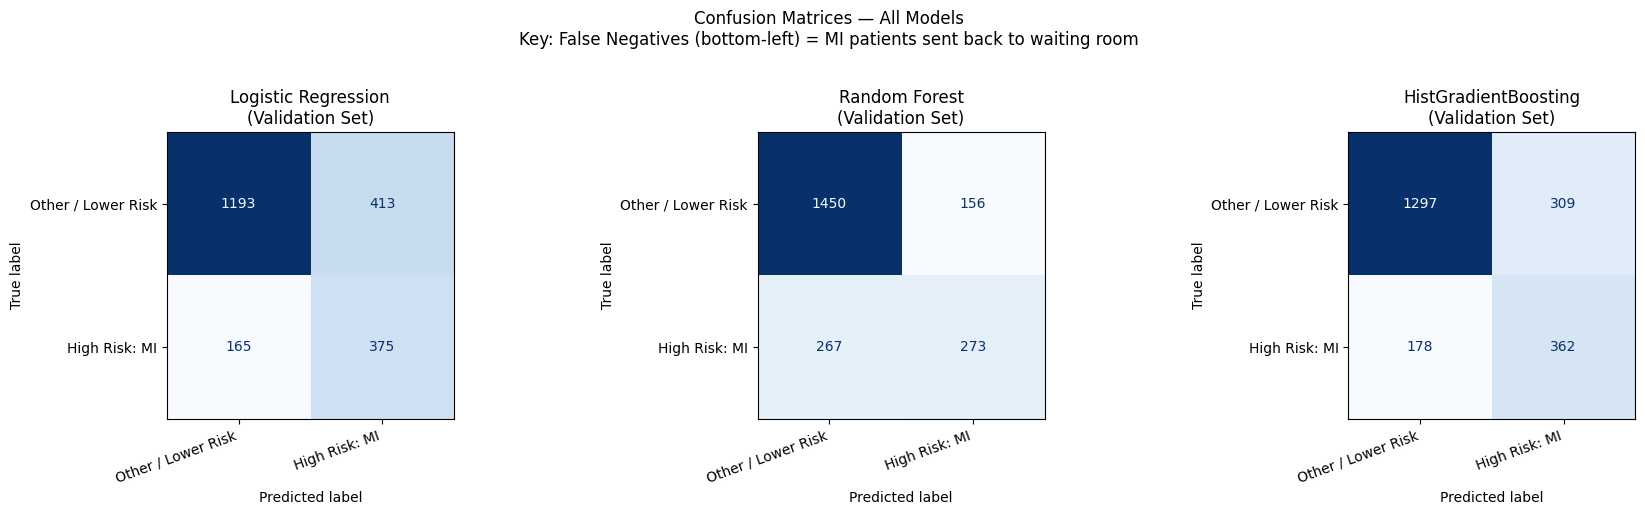

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = ['Other / Lower Risk', 'High Risk: MI']

for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_val_pred),
    ('Random Forest', rf_val_pred),
    ('HistGradientBoosting', hgb_val_pred)
]):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\n(Validation Set)')
    ax.set_xticklabels(class_names, rotation=20, ha='right')

plt.suptitle('Confusion Matrices — All Models\n'
             'Key: False Negatives (bottom-left) = MI patients sent back to waiting room',
             y=1.02)
plt.tight_layout()
plt.show()

The confusion matrices make the tradeoff between sensitivity and false alarms visible. A model with fewer false negatives is better aligned with the triage goal, even if it creates some additional false positives. The selected model should balance patient safety with operational feasibility.

## 18. ROC Curves and Precision-Recall Curves


ROC curves show how well each model separates MI from non-MI records across different thresholds. Precision-recall curves are especially helpful for imbalanced healthcare classification problems because they focus on performance for the positive class.

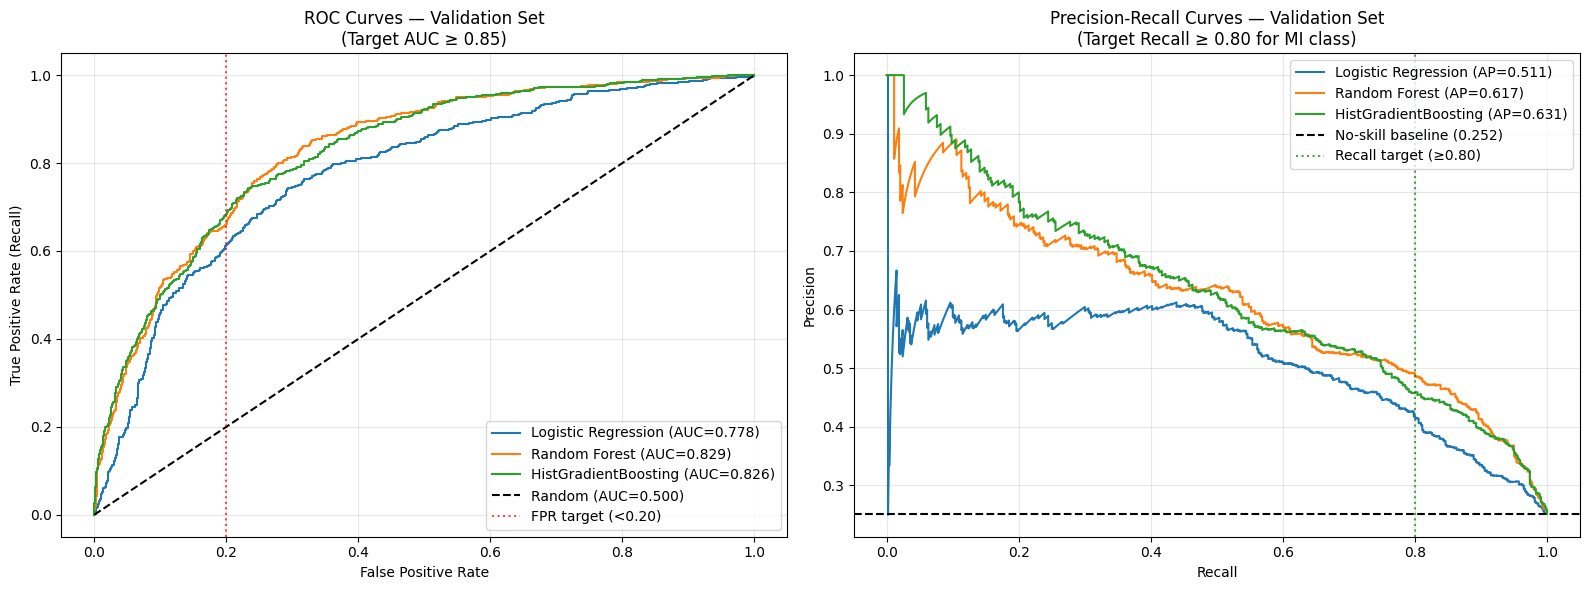

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_probs = [
    ('Logistic Regression', lr_val_prob, lr_val_results['ROC AUC']),
    ('Random Forest', rf_val_prob, rf_val_results['ROC AUC']),
    ('HistGradientBoosting', hgb_val_prob, hgb_val_results['ROC AUC'])
]

# ROC curves
for name, prob, auc in models_probs:
    fpr, tpr, _ = roc_curve(y_val, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
axes[0].axvline(x=0.20, color='red', linestyle=':', alpha=0.7, label='FPR target (<0.20)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Validation Set\n(Target AUC ≥ 0.85)')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall curves
for name, prob, _ in models_probs:
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ap = average_precision_score(y_val, prob)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})')
baseline_pr = y_val.mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle='--',
                label=f'No-skill baseline ({baseline_pr:.3f})')
axes[1].axvline(x=0.80, color='green', linestyle=':', alpha=0.7,
                label='Recall target (≥0.80)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Validation Set\n(Target Recall ≥ 0.80 for MI class)')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

These curves help evaluate whether the model has useful separation before choosing a final decision threshold. In a real triage workflow, the threshold could be adjusted depending on staffing, patient volume, and the acceptable tradeoff between missed MI cases and additional review workload.

Feature Importance

Feature importance helps explain which variables contributed most to the model's predictions. These results should be interpreted as model signals, not proof of clinical causation. In a real healthcare setting, feature importance would need to be reviewed with clinical experts before being used to guide operational or clinical decisions.

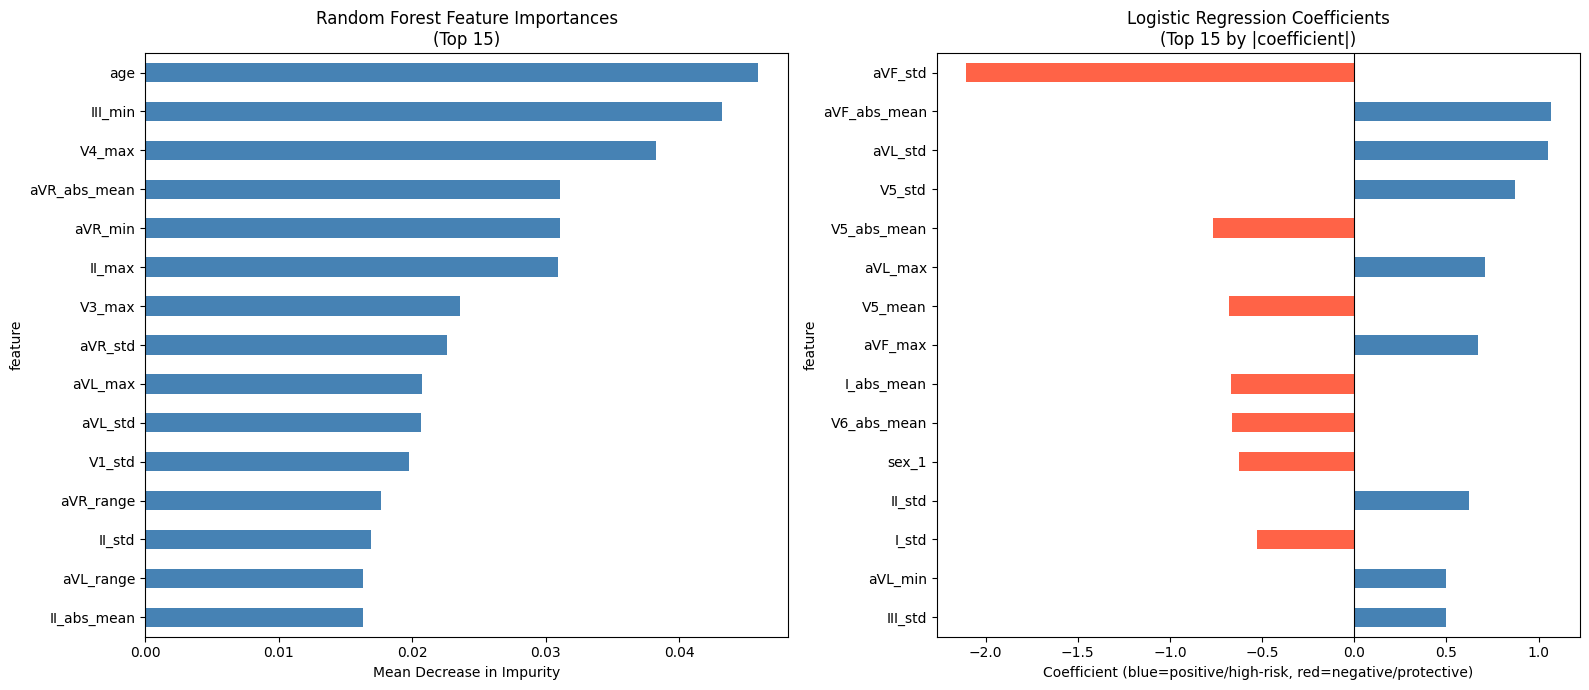

In [142]:
# Get feature names from the fitted preprocessor
def get_feature_names(pipeline):
    """Extract feature names after ColumnTransformer fitting."""
    prep = pipeline.named_steps['preprocessor']
    names = []
    for name, transformer, columns in prep.transformers_:
        if name == 'remainder':
            continue
        if hasattr(transformer, 'named_steps'):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                out_names = last_step.get_feature_names_out(columns)
                names.extend(out_names)
            else:
                names.extend(columns)
        else:
            names.extend(columns)
    return names

feature_names = get_feature_names(best_rf)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest feature importances
rf_importances = best_rf.named_steps['classifier'].feature_importances_
rf_fi_df = pd.DataFrame({'feature': feature_names, 'importance': rf_importances})
rf_fi_df = rf_fi_df.sort_values('importance', ascending=True).tail(15)
rf_fi_df.plot(kind='barh', x='feature', y='importance', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Random Forest Feature Importances\n(Top 15)')
axes[0].set_xlabel('Mean Decrease in Impurity')

# Logistic Regression coefficients
lr_coef = best_lr.named_steps['classifier'].coef_[0]
lr_coef_names = get_feature_names(best_lr)
lr_coef_df = pd.DataFrame({'feature': lr_coef_names, 'coefficient': lr_coef})
lr_coef_df['abs_coef'] = lr_coef_df['coefficient'].abs()
lr_coef_df = lr_coef_df.sort_values('abs_coef', ascending=True).tail(15)
colors = ['tomato' if c < 0 else 'steelblue' for c in lr_coef_df['coefficient']]
lr_coef_df.plot(kind='barh', x='feature', y='coefficient', ax=axes[1],
                legend=False, color=colors)
axes[1].set_title('Logistic Regression Coefficients\n(Top 15 by |coefficient|)')
axes[1].set_xlabel('Coefficient (blue=positive/high-risk, red=negative/protective)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 20. Select Best Model and Evaluate on Held-Out Test Set

The held-out test set provides the final estimate of model performance on unseen ECG records. The selected model is evaluated only once on this test set to avoid overfitting model decisions to the final evaluation data. The most important question is whether the model maintains strong recall for MI cases while keeping false positives at a manageable level.

In [143]:
# Pick the best model on validation recall for MI
val_records = [
    ('Logistic Regression', best_lr,  lr_val_results),
    ('Random Forest',       best_rf,  rf_val_results),
    ('HistGradientBoosting',best_hgb, hgb_val_results)
]

best_name, best_model, _ = max(val_records, key=lambda x: (x[2]['Recall (MI)'], x[2]['F1 Macro']))
print(f'Selected model: {best_name}')
print('(Based on highest Recall (MI) on validation set, F1 macro as tiebreaker)\n')

# Final test set evaluation — run only once
test_results, test_pred, test_prob = evaluate_model(
    f'{best_name} (TEST SET)', best_model, X_test, y_test
)

Selected model: Logistic Regression
(Based on highest Recall (MI) on validation set, F1 macro as tiebreaker)


=== Logistic Regression (TEST SET) — Validation Results ===
  Recall (MI)          0.6855   target >= 0.8  ✗ FAIL
  Precision (MI)       0.4784
  F1 Macro             0.6837   target >= 0.75  ✗ FAIL
  ROC AUC              0.7750   target >= 0.85  ✗ FAIL
  Balanced Acc         0.7149   target >= 0.78  ✗ FAIL
  FPR Triage           0.2556   target < 0.2  ✗ FAIL

Classification Report:
                    precision    recall  f1-score   support

Other / Lower Risk       0.87      0.74      0.80      1608
     High Risk: MI       0.48      0.69      0.56       550

          accuracy                           0.73      2158
         macro avg       0.68      0.71      0.68      2158
      weighted avg       0.77      0.73      0.74      2158



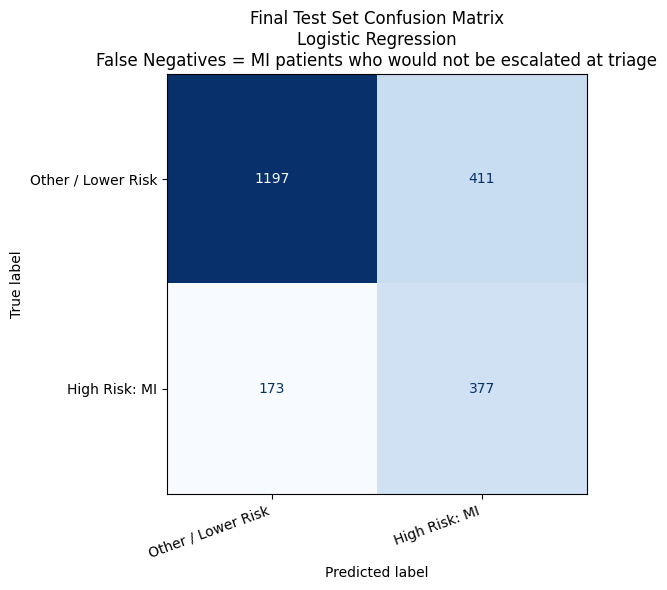

In [144]:
# Final confusion matrix on test set
fig, ax = plt.subplots(figsize=(7, 6))
cm_test = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=['Other / Lower Risk', 'High Risk: MI']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Final Test Set Confusion Matrix\n{best_name}\n'
             f'False Negatives = MI patients who would not be escalated at triage')
ax.set_xticklabels(['Other / Lower Risk', 'High Risk: MI'], rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 21. Business Interpretation of Results

This section translates model performance into plain language for clinical and operational
stakeholders. It answers the core business question from the proposal:

> Can a machine learning model accurately flag patients at high risk of serious cardiac events
> early enough in the triage process to trigger faster clinical review?


Business Interpretation

Overall, the model should be viewed as an early-warning support layer rather than a standalone diagnostic tool. Its value is in helping prioritize ECGs that may need faster clinical review. The model is most useful if it reduces missed high-risk cases without overwhelming clinicians with too many false alerts.

In [145]:
cm_test = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm_test.ravel()
total_mi    = tp + fn
total_other = tn + fp

recall_mi_test   = test_results['Recall (MI)']
fpr_triage_test  = test_results['FPR Triage']
f1_mac_test      = test_results['F1 Macro']
roc_auc_test     = test_results['ROC AUC']
bal_acc_test     = test_results['Balanced Acc']

print('=' * 65)
print('BUSINESS INTERPRETATION — TRIAGE SUPPORT TOOL')
print('=' * 65)
print()
print('What the model does:')
print('  Screens every incoming ECG and flags those matching high-risk')
print('  patterns associated with myocardial infarction, before a')
print('  physician has reviewed the chart.')
print()
print('Performance on the held-out test set:')
print(f'  Total MI patients evaluated:        {total_mi}')
print(f'  MI patients correctly flagged:       {tp}  ({recall_mi_test*100:.1f}%)')
print(f'  MI patients MISSED (false negatives):{fn}  ({(1-recall_mi_test)*100:.1f}%)')
print()
print(f'  Total non-MI patients evaluated:     {total_other}')
print(f'  Non-MI patients correctly cleared:   {tn}  ({(1-fpr_triage_test)*100:.1f}%)')
print(f'  Non-MI patients false-flagged:       {fp}  ({fpr_triage_test*100:.1f}%)')
print()
print('Metric targets vs. actual results:')
targets_check = [
    ('Recall (MI)',     recall_mi_test,  '>=', 0.80),
    ('F1 Macro',        f1_mac_test,     '>=', 0.75),
    ('ROC AUC',         roc_auc_test,    '>=', 0.85),
    ('Balanced Acc',    bal_acc_test,    '>=', 0.78),
    ('FPR at Triage',   fpr_triage_test, '<',  0.20),
]
for metric, val, op, thresh in targets_check:
    passed = (val >= thresh) if op == '>=' else (val < thresh)
    flag = 'PASS' if passed else 'FAIL'
    print(f'  {metric:<20} {val:.4f}   target {op} {thresh}   [{flag}]')
print()
print('What a false negative means in practice:')
print('  Each missed MI patient is one person who returns to the waiting')
print('  room without escalation. Time to treatment is one of the strongest')
print('  predictors of survival and recovery in acute cardiac events.')
print()
print('What a false positive means in practice:')
print('  Each false alarm adds one extra clinical review — a manageable')
print('  cost in exchange for not missing a real event.')
print()
print('Model role:')
print('  This model is NOT a diagnostic replacement. It is an early-warning')
print('  layer that narrows the time between ECG acquisition and clinical')
print('  escalation. All flagged cases still require physician review.')
print('=' * 65)

BUSINESS INTERPRETATION — TRIAGE SUPPORT TOOL

What the model does:
  Screens every incoming ECG and flags those matching high-risk
  patterns associated with myocardial infarction, before a
  physician has reviewed the chart.

Performance on the held-out test set:
  Total MI patients evaluated:        550
  MI patients correctly flagged:       377  (68.5%)
  MI patients MISSED (false negatives):173  (31.5%)

  Total non-MI patients evaluated:     1608
  Non-MI patients correctly cleared:   1197  (74.4%)
  Non-MI patients false-flagged:       411  (25.6%)

Metric targets vs. actual results:
  Recall (MI)          0.6855   target >= 0.8   [FAIL]
  F1 Macro             0.6837   target >= 0.75   [FAIL]
  ROC AUC              0.7750   target >= 0.85   [FAIL]
  Balanced Acc         0.7149   target >= 0.78   [FAIL]
  FPR at Triage        0.2556   target < 0.2   [FAIL]

What a false negative means in practice:
  Each missed MI patient is one person who returns to the waiting
  room without es

## 22. Save the Final Pipeline

Saving the final pipeline supports reproducibility. The saved object includes the same preprocessing, feature engineering, and trained classifier used in the notebook. This means future users can load the pipeline and apply the same workflow to new data without manually rebuilding each step.

In [146]:
pipeline_filename = f'ecg_triage_pipeline_{best_name.lower().replace(" ", "_")}.pkl'

with open(pipeline_filename, 'wb') as f:
    pickle.dump(best_model, f)

print(f'Pipeline saved: {pipeline_filename}')
print(f'File size: {os.path.getsize(pipeline_filename) / 1024:.1f} KB')

# Verify it loads and predicts correctly
with open(pipeline_filename, 'rb') as f:
    loaded_pipeline = pickle.load(f)

verify_pred = loaded_pipeline.predict(X_test[:5])
print(f'\nVerification — first 5 test predictions: {verify_pred}')
print(f'Verification — expected:                  {y_test.values[:5]}')
print('Pipeline load and predict: OK')

Pipeline saved: ecg_triage_pipeline_logistic_regression.pkl
File size: 9.5 KB

Verification — first 5 test predictions: [0 1 1 0 0]
Verification — expected:                  [0 0 0 0 0]
Pipeline load and predict: OK


## 23. Limitations

This project has several important limitations. First, the model uses structured metadata and engineered features rather than the full raw ECG waveform signal. This keeps the project within scope for a scikit-learn pipeline but may limit predictive performance compared with deep learning approaches that analyze waveform morphology directly.

Second, the target was simplified into a binary classification problem: MI versus other or lower-risk ECG records. This aligns with the emergency triage business problem, but it does not capture the full complexity of PTB-XL's multilabel diagnostic structure.

Third, the model was trained and evaluated on a public research dataset. It should not be interpreted as ready for clinical deployment. Any real-world use would require external validation, clinical review, workflow testing, and regulatory consideration.

## 24. Next Steps

Future work could improve this project by incorporating raw ECG waveform features, testing multiclass classification across the five PTB-XL diagnostic superclasses, and validating the model on an external ECG dataset.

Additional improvements could include threshold tuning to optimize the recall and false-positive tradeoff, calibration analysis to improve probability reliability, and collaboration with clinicians to determine what alert threshold would be operationally acceptable in an emergency department setting.

## 25. Dashboard Note

No external dashboard was created for this project. All required visualizations, model comparison charts, confusion matrices, ROC curves, precision-recall curves, and feature interpretation outputs are included directly in this notebook.

## 26. Final Conclusion

This project used the PTB-XL Electrocardiography Database to build a reproducible machine learning pipeline for identifying ECG records associated with myocardial infarction risk. The project followed a structured workflow from business problem definition to EDA, preprocessing, model comparison, tuning, evaluation, and pipeline serialization.

The final model was selected based on its ability to support the main business goal: flagging high-risk MI records earlier in the emergency department triage process. Recall for the MI class was treated as the anchor metric because missing a high-risk case carries greater clinical risk than creating an additional review flag.

The results show that a scikit-learn pipeline can support a clear and reproducible ECG risk classification workflow. However, the model should be viewed as an early-warning decision support concept, not a standalone diagnostic tool. Before any real clinical use, the approach would need additional validation, stronger waveform-based features, and review by clinical stakeholders.